In [1]:
import scanpy as sc
import pandas as pd
import os

# 디렉토리 설정
data_dir = "/home/Data_Drive_8TB/kykim/colon/Macrophage/"
adatas = []
# 파일 리스트와 sample 이름 정의
files = {
    "M1_3hrs": "GSM5012288_M1_3hrs_scRNAseq_counts.csv.gz",
    "M1_6hrs": "GSM5012289_M1_6hrs_scRNAseq_counts.csv.gz",
    "M1_12hrs": "GSM5012290_M1_12hrs_scRNAseq_counts.csv.gz",
    "M1_24hrs": "GSM5012291_M1_24hrs_scRNAseq_counts.csv.gz",
    "M2_3hrs": "GSM5012292_M2_3hrs_scRNAseq_counts.csv.gz",
    "M2_6hrs": "GSM5012293_M2_6hrs_scRNAseq_counts.csv.gz",
    "M2_12hrs": "GSM5012294_M2_12hrs_scRNAseq_counts.csv.gz",
    "M2_24hrs": "GSM5012295_M2_24hrs_scRNAseq_counts.csv.gz"}

for sample_name, filename in files.items():
    file_path = os.path.join(data_dir, filename)
    
    # CSV 파일을 pandas DataFrame으로 불러오기 (index_col=0 은 gene명 기준)
    df = pd.read_csv(file_path, index_col=0)
    
    # DataFrame을 AnnData로 변환
    adata = sc.AnnData(df.transpose())  # cells x genes 형태로 transpose 필요
    adata.obs['sample'] = sample_name
    
    # Cell 이름 prefix로 구분 가능하도록 바꾸기
    adata.obs_names = [f"{sample_name}_{cell}" for cell in adata.obs_names]
    
    adatas.append(adata)

# 병합
adata = adatas[0].concatenate(adatas[1:], batch_key=None)  # sample은 이미 obs에 들어감
def assign_cell_type(sample):
    if sample.startswith("Mac_"):
        return "M0"
    elif sample.startswith("M1_"):
        return "M1"
    elif sample.startswith("M2_"):
        return "M2"
    else:
        return "Unknown"

adata.obs['cell_type'] = adata.obs['sample'].apply(assign_cell_type)
adata.obs['type'] = 'train_data'
print(adata.obs['cell_type'].value_counts())
import scanpy as sc

# h5ad 파일 경로
file_path = '/home/Data_Drive_8TB/kykim/GC/Macrophage.h5ad'

# h5ad 파일 읽기
trainadata = sc.read_h5ad(file_path)
import pandas as pd
import numpy as np
import scipy.sparse as sp

# obs, var를 빈 DataFrame으로 초기화
trainadata.obs = pd.DataFrame(index=trainadata.obs_names)
trainadata.var = pd.DataFrame(index=trainadata.var_names)

# uns를 빈 딕셔너리로 초기화
trainadata.uns = {}

# obsm, varm을 빈 dict로 초기화
trainadata.obsm = {}
trainadata.varm = {}

# layers를 빈 dict로 초기화
trainadata.layers = {}

# obsp를 빈 dict로 초기화
trainadata.obsp = {}
trainadata.obs['type'] = 'predict_data'
trainadata.obs['cell_type'] = 'predict_data'
trainadata.obs['sample'] = 'predict_data'

/tmp/ipykernel_696305/301119643.py:35: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adatas[0].concatenate(adatas[1:], batch_key=None)  # sample은 이미 obs에 들어감


cell_type
M1    1904
M2    1527
Name: count, dtype: int64


In [2]:
pd.set_option('display.max_columns', 10)    # 모든 열 보기
pd.set_option('display.max_rows', 10)       # 모든 행 보기
trainadata.obs['sample'].value_counts().reset_index(name='count')


,sample,count
0,predict_data,6253


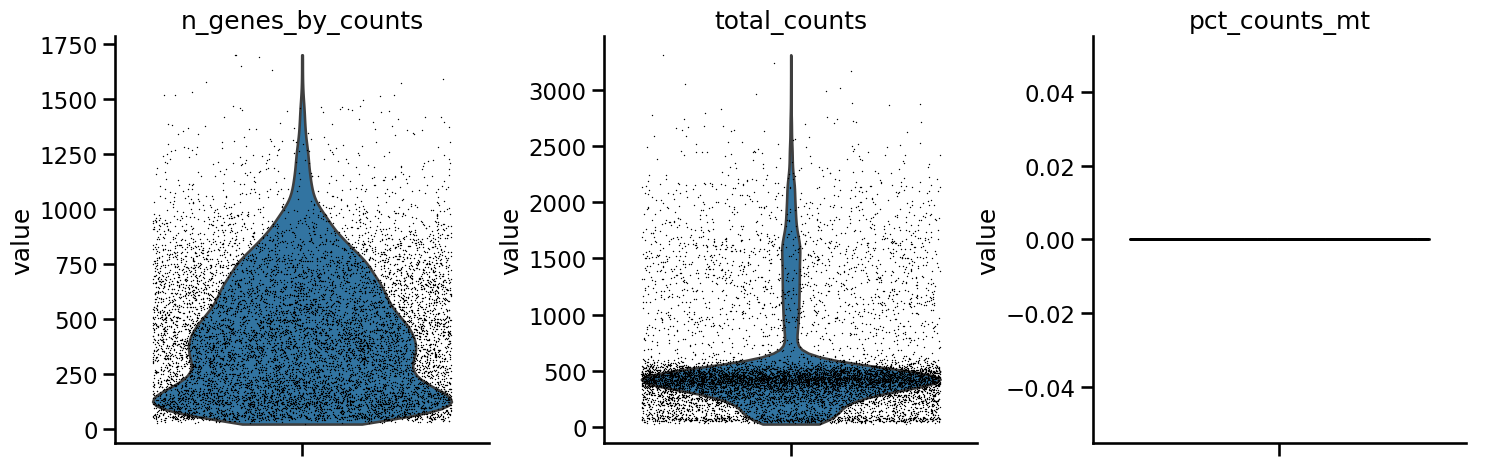

(9684, 5000)


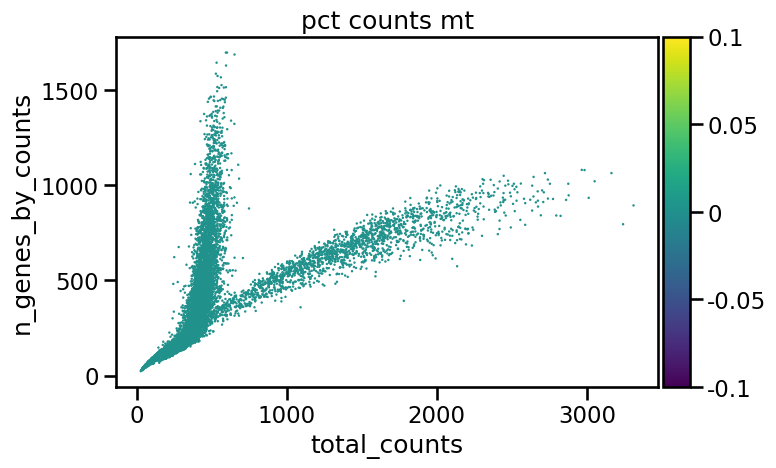

(8686, 4919)


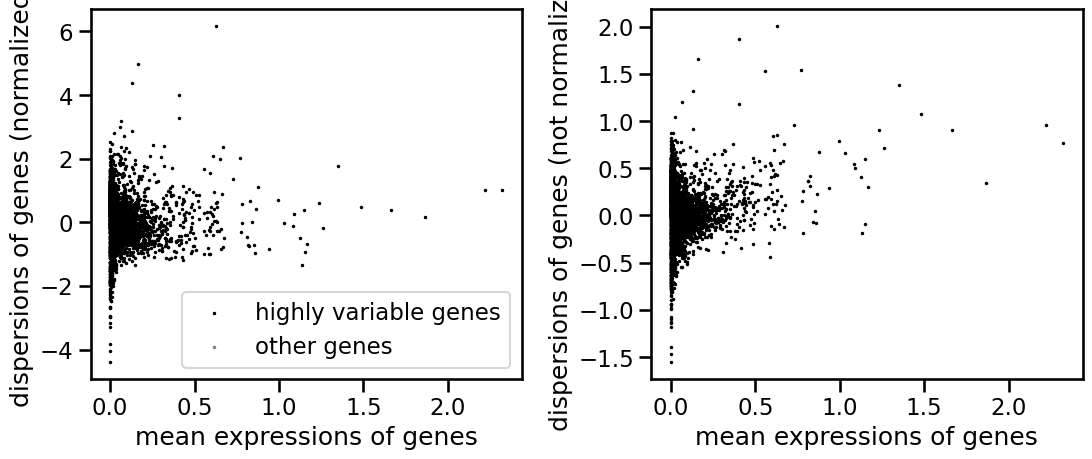

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


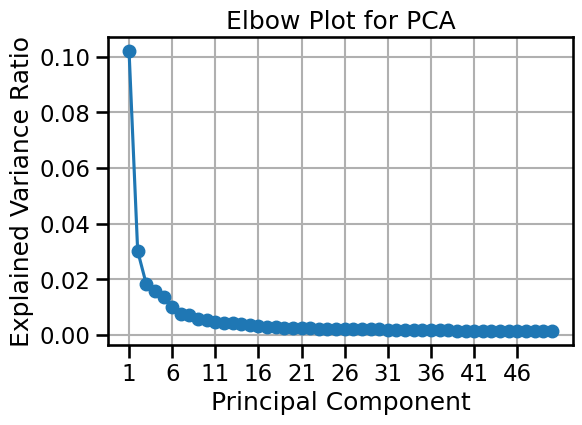

In [3]:
import anndata as ad

# outer join으로 concat (관측값 방향으로 합치기: axis=0)
adata = ad.concat([adata, trainadata], join='inner', axis=0)
import scanpy as sc
from scib.integration import combat

import scanpy as sc
adata.layers["counts"] = adata.X.copy()
raw_var_names = adata.var_names.copy()

rawadata = adata.copy()

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


print(adata.X.shape)
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
print(adata.X.shape)

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=5000,batch_key="type")
sc.pl.highly_variable_genes(adata)
adata = adata[:, adata.var['highly_variable']]

import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

sc.tl.pca(adata)
explained_variance_ratio = adata.uns["pca"]["variance_ratio"]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o", linestyle="-")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Elbow Plot for PCA")
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, step=5))
plt.grid()
plt.show()

sc.tl.pca(adata, n_comps=46)

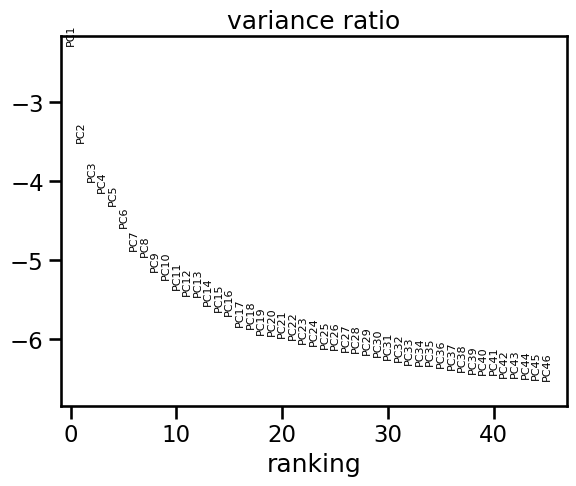

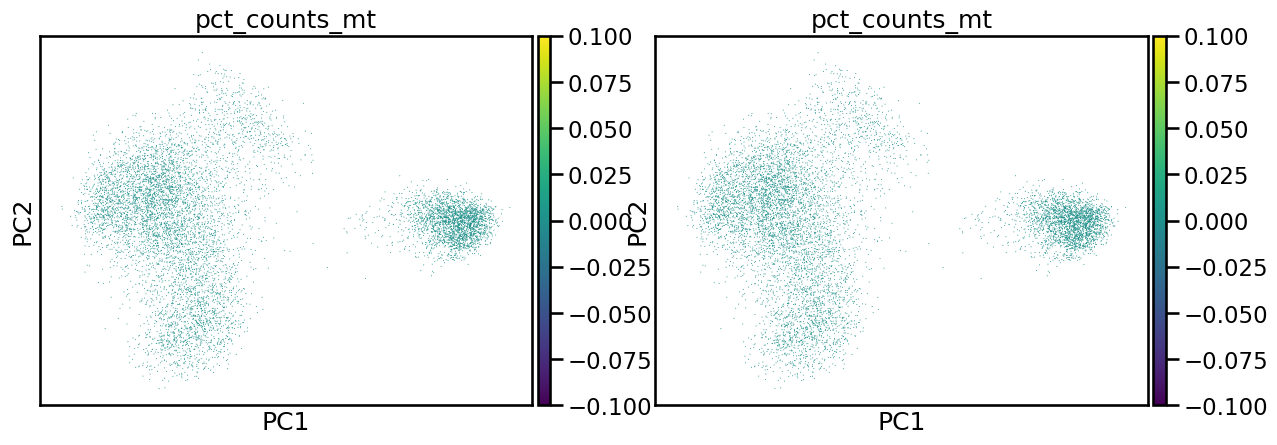

In [4]:
sc.pl.pca_variance_ratio(adata, n_pcs=46, log=True)
sc.pl.pca(
    adata,
    color=["pct_counts_mt", "pct_counts_mt"],
    ncols=2,
    size=2,
)
trainadata = adata[adata.obs['type'] == 'train_data'].copy()
predictadata = adata[adata.obs['type'] == 'predict_data'].copy()

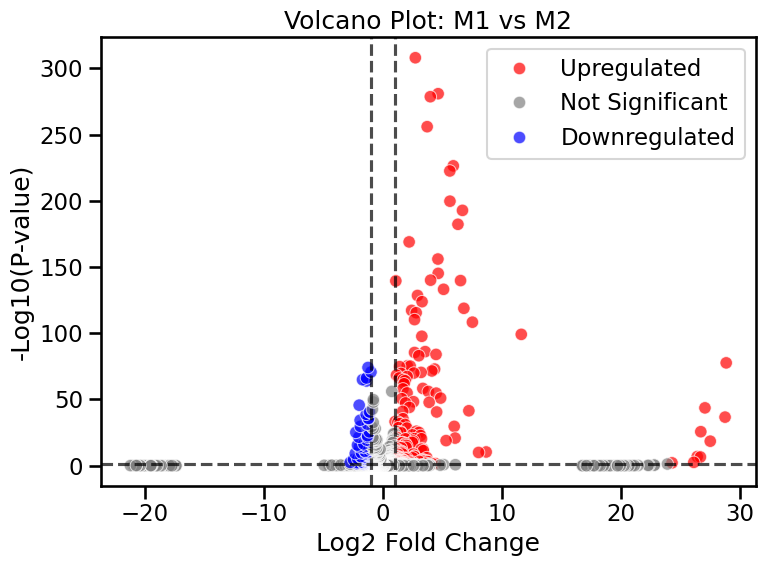

['GBP5', 'CXCL10', 'UBD', 'CD274', 'CMPK2', 'CCL8', 'CXCL11', 'CXCL9', 'IFIT1', 'GBP1', 'GBP4', 'AIM2', 'TRIM22', 'P2RY14', 'IFIT2', 'TAP1', 'FCGR1A', 'PSMB9', 'ANKRD22', 'IFITM1']


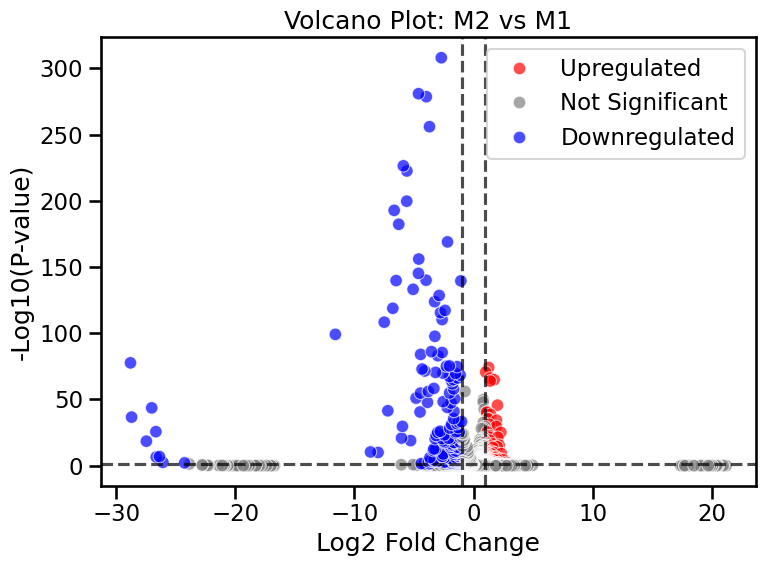

['SIGLEC10', 'LPL', 'CXCR4', 'CITED2', 'PTPN3', 'SLC25A29', 'SPP1', 'CD300LB', 'EGR3', 'ALOX15', 'NET1', 'FYN', 'IL24', 'SLC5A3', 'SMAD6', 'SRGAP1', 'CSF2', 'FAM30A', 'TSC22D3', 'NOL4L']


In [5]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 특정 그룹을 묶어서 새로운 참조 그룹 생성
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# 🔹 그룹 병합 함수
def merge_groups(adata, groupby, group1, ref_groups):
    adata = adata.copy()
    ref_name = "_".join(ref_groups)  # 예: "M2_M3"
    adata.obs[groupby] = adata.obs[groupby].astype(str)
    
    # ref_groups를 하나의 그룹으로 묶기
    adata.obs[groupby] = adata.obs[groupby].replace(ref_groups, ref_name)
    
    return adata, ref_name

# 🔹 볼케이노 플롯 함수
def plot_volcano(deg_results, group1, reference):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=deg_results, x="logFC", y="neg_log_pval", hue="significance",
                    palette={"Upregulated": "red", "Downregulated": "blue", "Not Significant": "gray"},
                    alpha=0.7)

    plt.axvline(x=1, linestyle='--', color='black', alpha=0.7)
    plt.axvline(x=-1, linestyle='--', color='black', alpha=0.7)
    plt.axhline(y=-np.log10(0.05), linestyle='--', color='black', alpha=0.7)
    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10(P-value)")
    plt.title(f"Volcano Plot: {group1} vs {reference}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 🔹 DEG 분석 함수 + Upregulated 유전자 반환 (log2FC ≤ 5)
def run_deg_analysis(adata, groupby, group1, ref_groups, logfc_threshold=1, pval_threshold=0.05, top_n=20):
    # 그룹 병합
    adata, reference = merge_groups(adata, groupby, group1, ref_groups)
    
    # DEG 분석 (Wilcoxon rank-sum test)
    sc.tl.rank_genes_groups(adata, groupby=groupby, groups=[group1], reference=reference, method='wilcoxon')

    # 결과 저장
    result = adata.uns['rank_genes_groups']
    deg_results = pd.DataFrame({
        "gene": result['names'][group1],
        "logFC": result['logfoldchanges'][group1],
        "pval": result['pvals'][group1]
    })

    # 0을 작은 값으로 대체하여 log 변환 가능하게 처리
    deg_results["pval"] = deg_results["pval"].replace(0, 1e-300)
    deg_results["neg_log_pval"] = -np.log10(deg_results["pval"])

    # DEG 필터링 및 라벨링
    deg_results["significance"] = "Not Significant"
    deg_results.loc[(deg_results["logFC"] > logfc_threshold) & (deg_results["pval"] < pval_threshold), "significance"] = "Upregulated"
    deg_results.loc[(deg_results["logFC"] < -logfc_threshold) & (deg_results["pval"] < pval_threshold), "significance"] = "Downregulated"

    # 볼케이노 플롯
    plot_volcano(deg_results, group1, reference)

    # 🔹 log2FC ≤ 5 조건 추가 후 상위 20개 Upregulated 유전자 추출
    upregulated_genes = deg_results[
        (deg_results["logFC"] > logfc_threshold) & 
        (deg_results["logFC"] <= 10000) & 
        (deg_results["pval"] < pval_threshold)
    ].sort_values("logFC", ascending=False)["gene"].head(top_n).tolist()

    return upregulated_genes


upregulated_gene_list = run_deg_analysis(trainadata, groupby="cell_type", group1="M1", ref_groups=["M2"])
print(upregulated_gene_list)
upregulated_gene_list = run_deg_analysis(trainadata, groupby="cell_type", group1="M2", ref_groups=["M1"])
print(upregulated_gene_list)

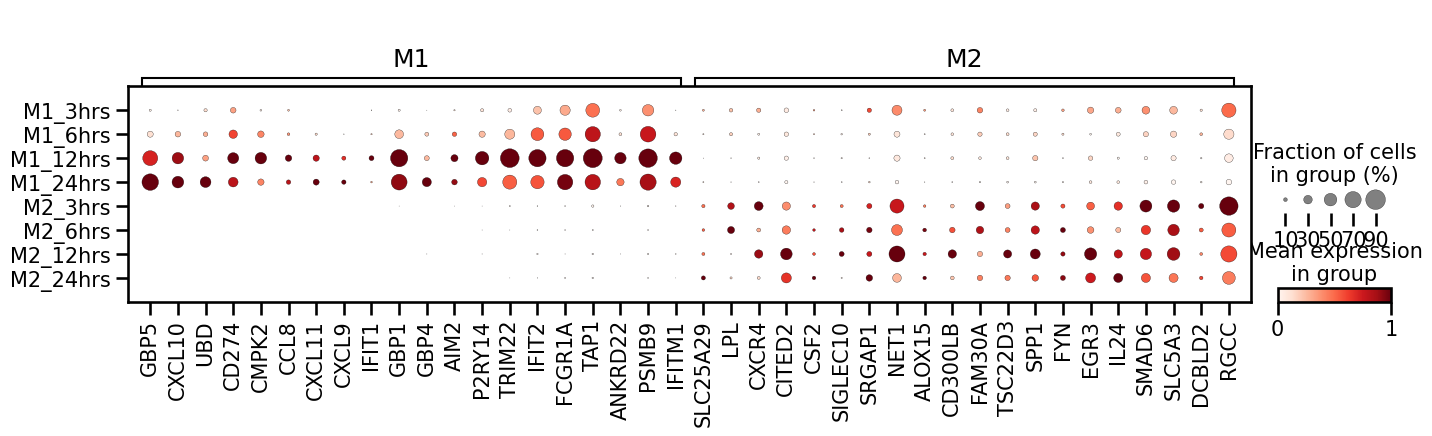

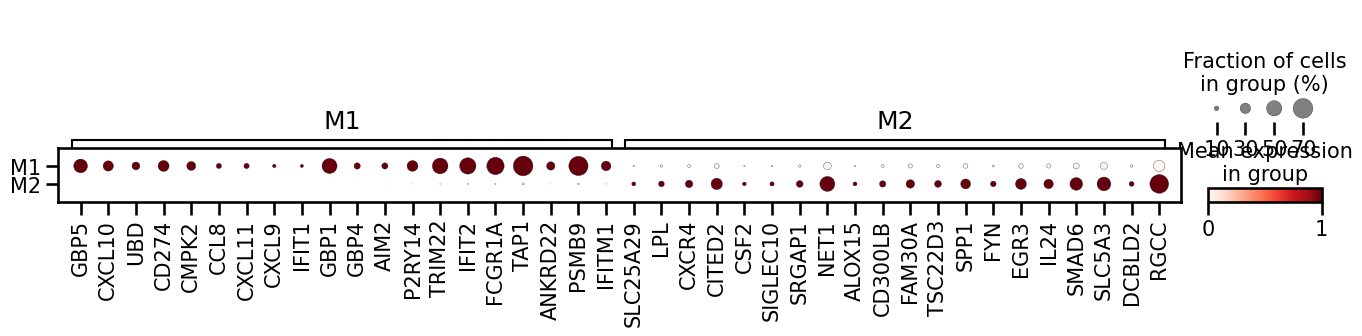

In [6]:
marker_genes = {
    "M1": ['GBP5', 'CXCL10', 'UBD', 'CD274', 'CMPK2', 'CCL8', 'CXCL11', 'CXCL9', 'IFIT1', 'GBP1', 'GBP4', 'AIM2', 'P2RY14', 'TRIM22', 'IFIT2', 'FCGR1A', 'TAP1', 'ANKRD22', 'PSMB9', 'IFITM1'],
    "M2": ['SLC25A29', 'LPL', 'CXCR4', 'CITED2', 'CSF2', 'SIGLEC10', 'SRGAP1', 'NET1', 'ALOX15', 'CD300LB', 'FAM30A', 'TSC22D3', 'SPP1', 'FYN', 'EGR3', 'IL24', 'SMAD6', 'SLC5A3', 'DCBLD2', 'RGCC']
}
marker_genes = {cat: [gene for gene in genes if gene in adata.var_names] 
                  for cat, genes in marker_genes.items()}
marker_genes = {cat: genes for cat, genes in marker_genes.items() if genes}

sc.pl.dotplot(trainadata, marker_genes, groupby="sample", standard_scale="var")
sc.pl.dotplot(trainadata, marker_genes, groupby="cell_type", standard_scale="var")

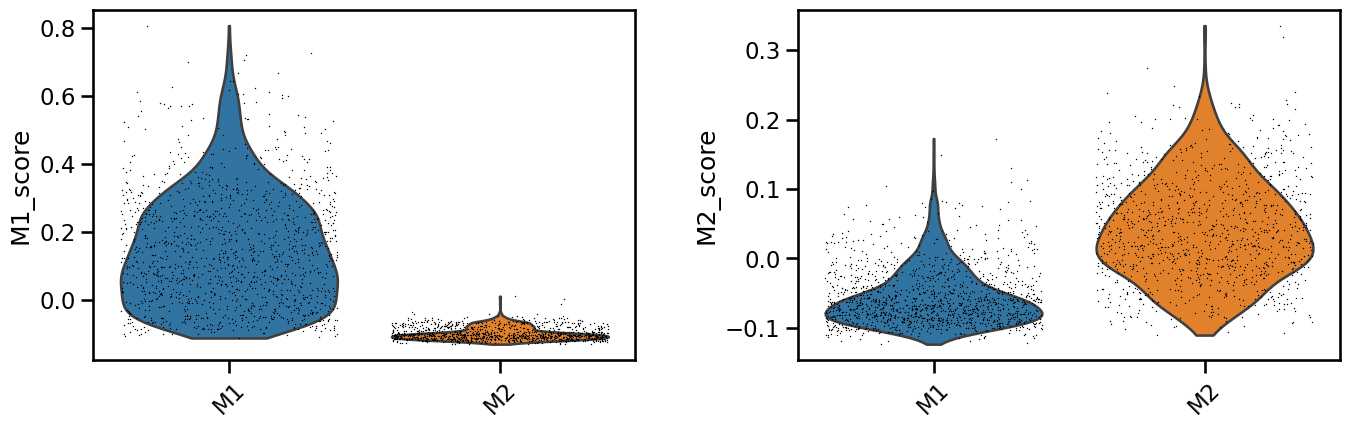

In [7]:
# 각 마커에 대해 score 계산
for label, genes in marker_genes.items():
    sc.tl.score_genes(trainadata, gene_list=genes, score_name=f'{label}_score', use_raw=False)

sc.pl.violin(trainadata, keys=['M1_score', 'M2_score'], groupby='cell_type', jitter=0.4, rotation=45)


In [8]:
import pandas as pd

# 🔹 각 cell type별 유전자 리스트 정의
marker_genes = {
    "M1": ['GBP5', 'CXCL10', 'UBD', 'CD274', 'CMPK2', 'CCL8', 'CXCL11', 'CXCL9', 'IFIT1', 'GBP1', 'GBP4', 'AIM2', 'P2RY14', 'TRIM22', 'IFIT2', 'FCGR1A', 'TAP1', 'ANKRD22', 'PSMB9', 'IFITM1'],
    "M2": ['SLC25A29', 'LPL', 'CXCR4', 'CITED2', 'CSF2', 'SIGLEC10', 'SRGAP1', 'NET1', 'ALOX15', 'CD300LB', 'FAM30A', 'TSC22D3', 'SPP1', 'FYN', 'EGR3', 'IL24', 'SMAD6', 'SLC5A3', 'DCBLD2', 'RGCC']
}

# 🔹 모든 유전자 리스트 통합
all_genes = list(set(sum(marker_genes.values(), [])))  # 중복 제거
dfT = pd.DataFrame(trainadata[:, all_genes].X.toarray(), columns=all_genes)
dfT['type'] = trainadata.obs['type'].values

dfP = pd.DataFrame(predictadata[:, all_genes].X.toarray(), columns=all_genes)
dfP['type'] = predictadata.obs['type'].values

df = pd.concat([dfT, dfP], axis=0)

In [9]:
dfT['cell_type'] = trainadata.obs['cell_type'].values
dfT = dfT.drop('type',axis = 1)

dfP = dfP.drop('type',axis = 1)

In [10]:
dfT

,IL24,SLC5A3,TSC22D3,RGCC,CSF2,...,CCL8,P2RY14,SIGLEC10,CXCL10,cell_type
0,0.0,0.625281,0.0,0.527693,0.0,...,0.000000,0.0,0.0,0.160207,M1
1,0.0,0.168234,0.0,0.902477,0.0,...,0.000000,0.0,0.0,0.000000,M1
2,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,M1
3,0.0,0.516945,0.0,0.410567,0.0,...,2.847553,0.0,0.0,0.000000,M1
4,0.0,0.000000,0.0,0.185410,0.0,...,0.000000,0.0,0.0,0.000000,M1
...,...,...,...,...,...,...,...,...,...,...,...
2501,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,M2
2502,0.0,1.421025,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,M2
2503,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,M2
2504,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,M2


📊 Confusion Matrix:
[[249  25]
 [  3 225]]

📝 Classification Report:
              precision    recall  f1-score   support

          M1       0.99      0.91      0.95       274
          M2       0.90      0.99      0.94       228

    accuracy                           0.94       502
   macro avg       0.94      0.95      0.94       502
weighted avg       0.95      0.94      0.94       502



/tmp/ipykernel_696305/1172212121.py:45: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()



✅ Cross-Validation Accuracy Scores: [0.8187251  0.94411178 0.96806387 0.98403194 0.96407186]
📌 Mean CV Accuracy: 0.9358


/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:82: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


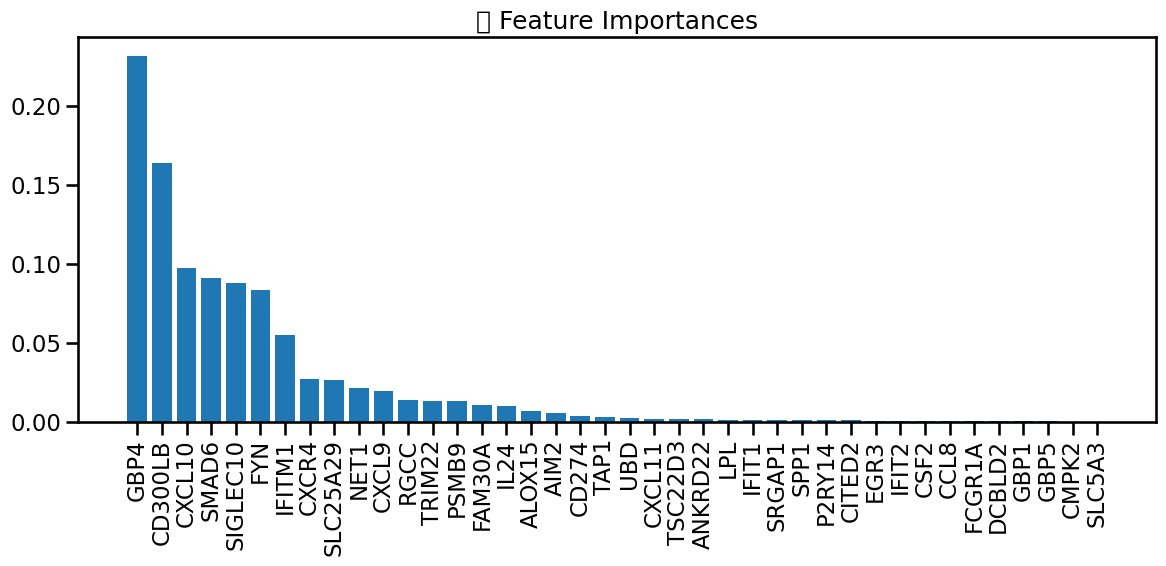

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Feature와 Label 분리
X = dfT.drop(columns='cell_type')
y = dfT['cell_type']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = X_train
X_test_scaled = X_test


# 4. 기본 RandomForest 모델 학습
rf = RandomForestClassifier(max_depth = 5, min_samples_leaf = 1, min_samples_split = 10, n_estimators = 200)               # 결과 재현을 위한 랜덤 시드)
rf.fit(X_train_scaled, y_train)

# 5. 예측 및 평가
y_pred = rf.predict(X_test_scaled)

print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n📝 Classification Report:")
print(classification_report(y_test, y_pred))

# 6. Feature Importance 시각화
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns[indices]

n = len(importances)  # or use min(20, len(importances))
plt.figure(figsize=(12, 6))
plt.title("📈 Feature Importances")
plt.bar(range(n), importances[indices[:n]], align="center")
plt.xticks(range(n), features[indices[:n]], rotation=90)
plt.tight_layout()


# 7. Cross-validation score (기본 모델 성능 확인)
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"\n✅ Cross-Validation Accuracy Scores: {cv_scores}")
print(f"📌 Mean CV Accuracy: {cv_scores.mean():.4f}")

In [12]:
# 8. GridSearchCV로 하이퍼파라미터 튜닝
param_grid = {
    'n_estimators': [50, 200],
    'max_depth': [None, 5, 20],
    'min_samples_split': [1, 10],
    'min_samples_leaf': [1, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n🔍 Best Parameters: {grid_search.best_params_}")
print(f"🎯 Best CV Score: {grid_search.best_score_:.4f}")

# 최적 모델로 테스트셋 평가
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("\n🧪 Test Set Evaluation (Best Model):")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
36 fits failed out of a total of 72.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
36 fits failed with the following error:
Traceback (most recent call last):
  File "/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/base.py", line 436, in _validate_params
    val


🔍 Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
🎯 Best CV Score: 0.9591

🧪 Test Set Evaluation (Best Model):
[[254  20]
 [  4 224]]
              precision    recall  f1-score   support

          M1       0.98      0.93      0.95       274
          M2       0.92      0.98      0.95       228

    accuracy                           0.95       502
   macro avg       0.95      0.95      0.95       502
weighted avg       0.95      0.95      0.95       502



In [13]:
# 예측 확률 추출
test_proba = rf.predict_proba(dfP.values)
test_pred = rf.predict(dfP.values)
# 클래스 라벨
class_labels = rf.classes_

# 확률 DataFrame 생성
proba_df = pd.DataFrame(test_proba, columns=[f'proba_{cls}' for cls in class_labels], index=predictadata.obs.index)

# cell_id와 predicted_cell_type 포함한 기본 DataFrame
test_pred_df = pd.DataFrame({
    'cell_id': predictadata.obs.index,
    'predicted_cell_type': test_pred
})

# 확률 정보 붙이기
test_pred_df = pd.concat([test_pred_df, proba_df.reset_index(drop=True)], axis=1)

# 결과 확인
test_pred_df


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,cell_id,predicted_cell_type,proba_M1,proba_M2
0,ACCAGTAGTAAGTGGC_8,M2,0.145600,0.854400
1,ACGCAGCGTATAATGG_8,M1,0.502858,0.497142
2,ATCATGGCAGTCAGAG_8,M1,0.716911,0.283089
3,ATTATCCTCTTCCTTC_8,M2,0.422758,0.577242
4,CATCGAAAGTTCGATC_8,M1,0.526238,0.473762
...,...,...,...,...
6175,TTTAGTCAGCACAAAT.1_40,M1,0.865421,0.134579
6176,TTTAGTCGTCTGGTTA.1_40,M2,0.169702,0.830298
6177,TTTCACATCATTGCGA.1_40,M2,0.357260,0.642740
6178,TTTGGTTGTGAGCTCC.1_40,M2,0.161250,0.838750


In [14]:
test_pred_df['predicted_cell_type'].value_counts()

predicted_cell_type
M1    3167
M2    3013
Name: count, dtype: int64

In [15]:
predictadata.obs['predict'] = test_pred_df['predicted_cell_type'].values

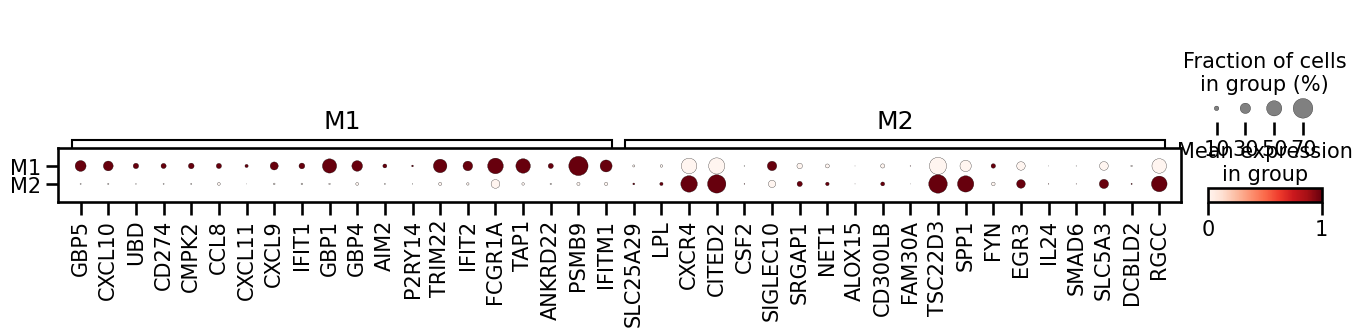

In [16]:
marker_genes = {cat: [gene for gene in genes if gene in predictadata.var_names] 
                  for cat, genes in marker_genes.items()}
marker_genes = {cat: genes for cat, genes in marker_genes.items() if genes}

sc.pl.dotplot(predictadata, marker_genes, groupby="predict", standard_scale="var")

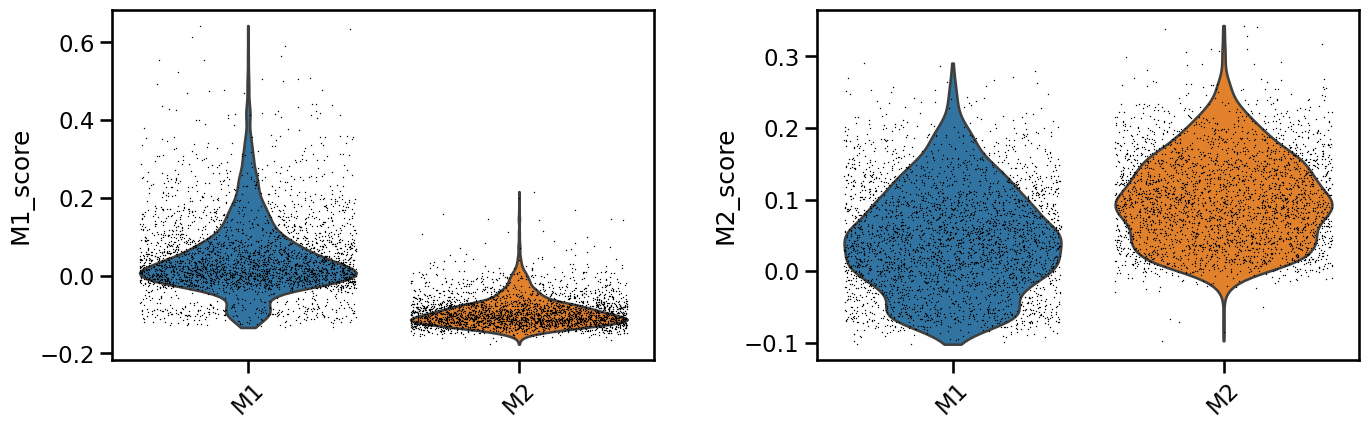

In [17]:
for label, genes in marker_genes.items():
    sc.tl.score_genes(predictadata, gene_list=genes, score_name=f'{label}_score', use_raw=False)

sc.pl.violin(predictadata, keys=['M1_score', 'M2_score'], groupby='predict', jitter=0.4, rotation=45)

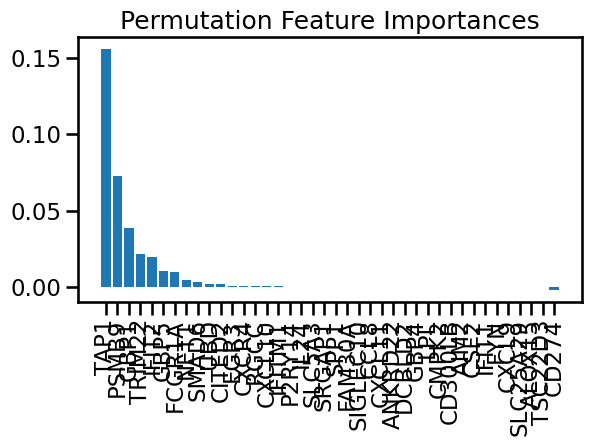

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()[::-1]

plt.bar(range(len(sorted_idx)), result.importances_mean[sorted_idx])
plt.xticks(range(len(sorted_idx)), X.columns[sorted_idx], rotation=90)
plt.title("Permutation Feature Importances")
plt.tight_layout()


# corr = trainadata.obs[['M0_score','M1_score','M2_score']].corr()
# sns.heatmap(corr, annot=True, cmap='coolwarm')


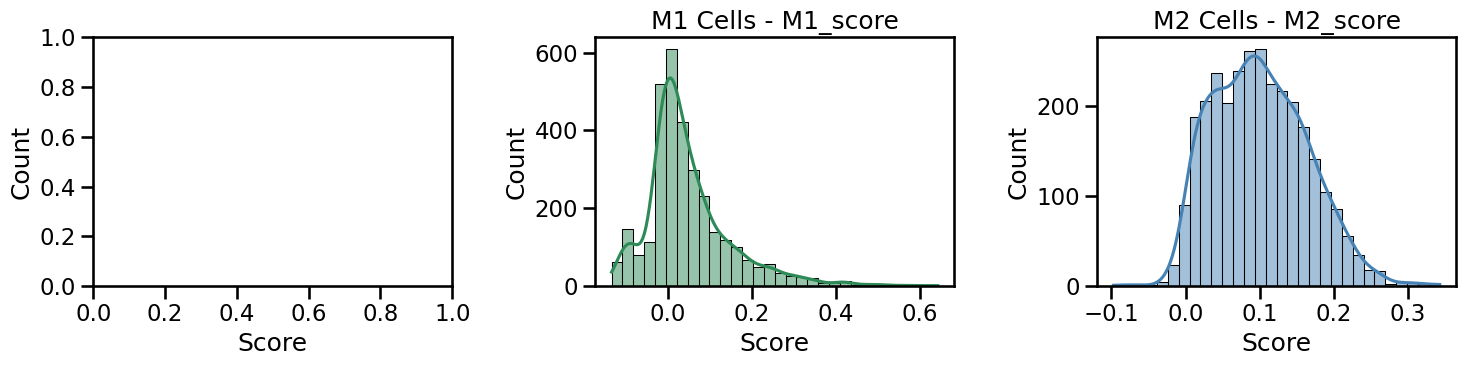

In [19]:
# 그룹별로 관련 score만 추출

df_M1 = predictadata.obs[predictadata.obs['predict'] == 'M1'][['M1_score']]
df_M2 = predictadata.obs[predictadata.obs['predict'] == 'M2'][['M2_score']]
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# M1
sns.histplot(df_M1['M1_score'], bins=30, kde=True, ax=axs[1], color='seagreen')
axs[1].set_title('M1 Cells - M1_score')

# M2
sns.histplot(df_M2['M2_score'], bins=30, kde=True, ax=axs[2], color='steelblue')
axs[2].set_title('M2 Cells - M2_score')

for ax in axs:
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


In [20]:
# 1. final 값을 복사해서 final_celltype 생성
predictadata.obs['final_celltype'] = predictadata.obs['predict'].copy()

# 2. Categorical이면 'Unknown'이 없을 때만 추가
if pd.api.types.is_categorical_dtype(predictadata.obs['final_celltype']):
    if 'Unknown' not in predictadata.obs['final_celltype'].cat.categories:
        predictadata.obs['final_celltype'] = predictadata.obs['final_celltype'].cat.add_categories(['Unknown'])

# 3. 조건별로 Unknown으로 변경
predictadata.obs.loc[(predictadata.obs['predict'] == 'M1') & (predictadata.obs['M1_score'] < 0), 'final_celltype'] = 'Unknown'
predictadata.obs.loc[(predictadata.obs['predict'] == 'M2') & (predictadata.obs['M2_score'] < 0), 'final_celltype'] = 'Unknown'
predictadata.obs['final_celltype'].value_counts()

/tmp/ipykernel_696305/121505063.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(predictadata.obs['final_celltype']):


final_celltype
M2         2939
M1         2157
Unknown    1084
Name: count, dtype: int64

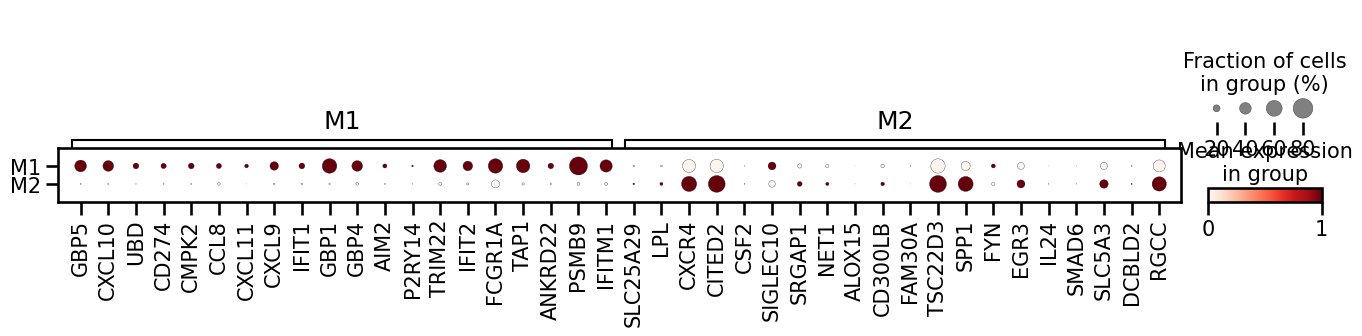

In [21]:
predictadata = predictadata[predictadata.obs['final_celltype'] != 'Unknown']
sc.pl.dotplot(predictadata, marker_genes, groupby="final_celltype", standard_scale="var")

/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/tools/_score_genes.py:169: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


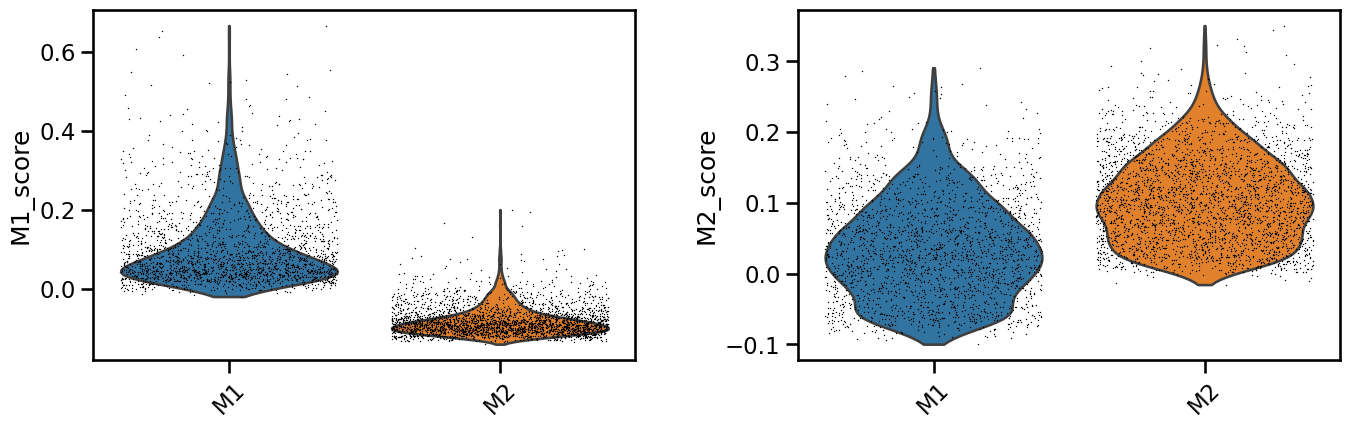

In [22]:
for label, genes in marker_genes.items():
    sc.tl.score_genes(predictadata, gene_list=genes, score_name=f'{label}_score', use_raw=False)

sc.pl.violin(predictadata, keys=['M1_score', 'M2_score'], groupby='final_celltype', jitter=0.4, rotation=45)

In [23]:
predictadata.obs['final_celltype'].value_counts()

final_celltype
M2    2939
M1    2157
Name: count, dtype: int64

In [334]:
predictadata.write("/home/Data_Drive_8TB/kykim/GC/predict.h5ad")

In [1]:
import scanpy as sc

# 경로 설정
adata_path = "/home/Data_Drive_8TB/kykim/GC/predict.h5ad" 

# 파일 불러오기
predictadata = sc.read_h5ad(adata_path)


In [3]:
marker_genes = {
    "M1": ['GBP5', 'CXCL10', 'UBD', 'CD274', 'CMPK2', 'CCL8', 'CXCL11', 'CXCL9', 'IFIT1', 'GBP1', 'GBP4', 'AIM2', 'P2RY14', 'TRIM22', 'IFIT2', 'FCGR1A', 'TAP1', 'ANKRD22', 'PSMB9', 'IFITM1'],
    "M2": ['SLC25A29', 'LPL', 'CXCR4', 'CITED2', 'CSF2', 'SIGLEC10', 'SRGAP1', 'NET1', 'ALOX15', 'CD300LB', 'FAM30A', 'TSC22D3', 'SPP1', 'FYN', 'EGR3', 'IL24', 'SMAD6', 'SLC5A3', 'DCBLD2', 'RGCC']
}

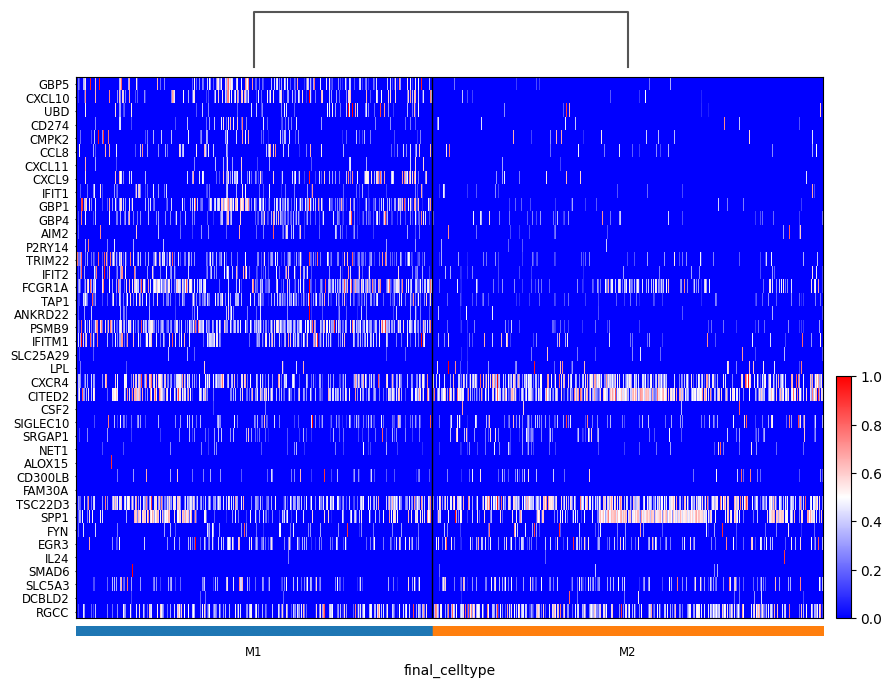

In [5]:
import scanpy as sc

# marker genes를 평탄화해서 하나의 리스트로 만들기
marker_gene_list = marker_genes["M1"] + marker_genes["M2"]
sc.pp.normalize_total(predictadata)
sc.pp.log1p(predictadata)
# 히트맵 그리기
sc.pl.heatmap(
    predictadata,
    var_names=marker_gene_list,
    groupby='final_celltype',       # cell type 별 평균 발현 보여줌
    use_raw=False,             # 필요한 경우 True로 (adata.raw에 데이터가 있을 경우)
    cmap='bwr',                # blue-white-red 색상
    swap_axes=True,            # 유전자가 x축
    dendrogram=True,           # 클러스터링
    standard_scale='var'       # 유전자별 z-score 정규화 (선택)
)


/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/Data_Drive_8TB/kykim/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/tmp/ipykernel_696305/2640945100.py:17: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  top_genes_unique = list(pd.unique(top_genes_per_cluster))
/tmp/ipykernel_696305/2640945100.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_positions = cluster_labels.reset_index(drop=True).g

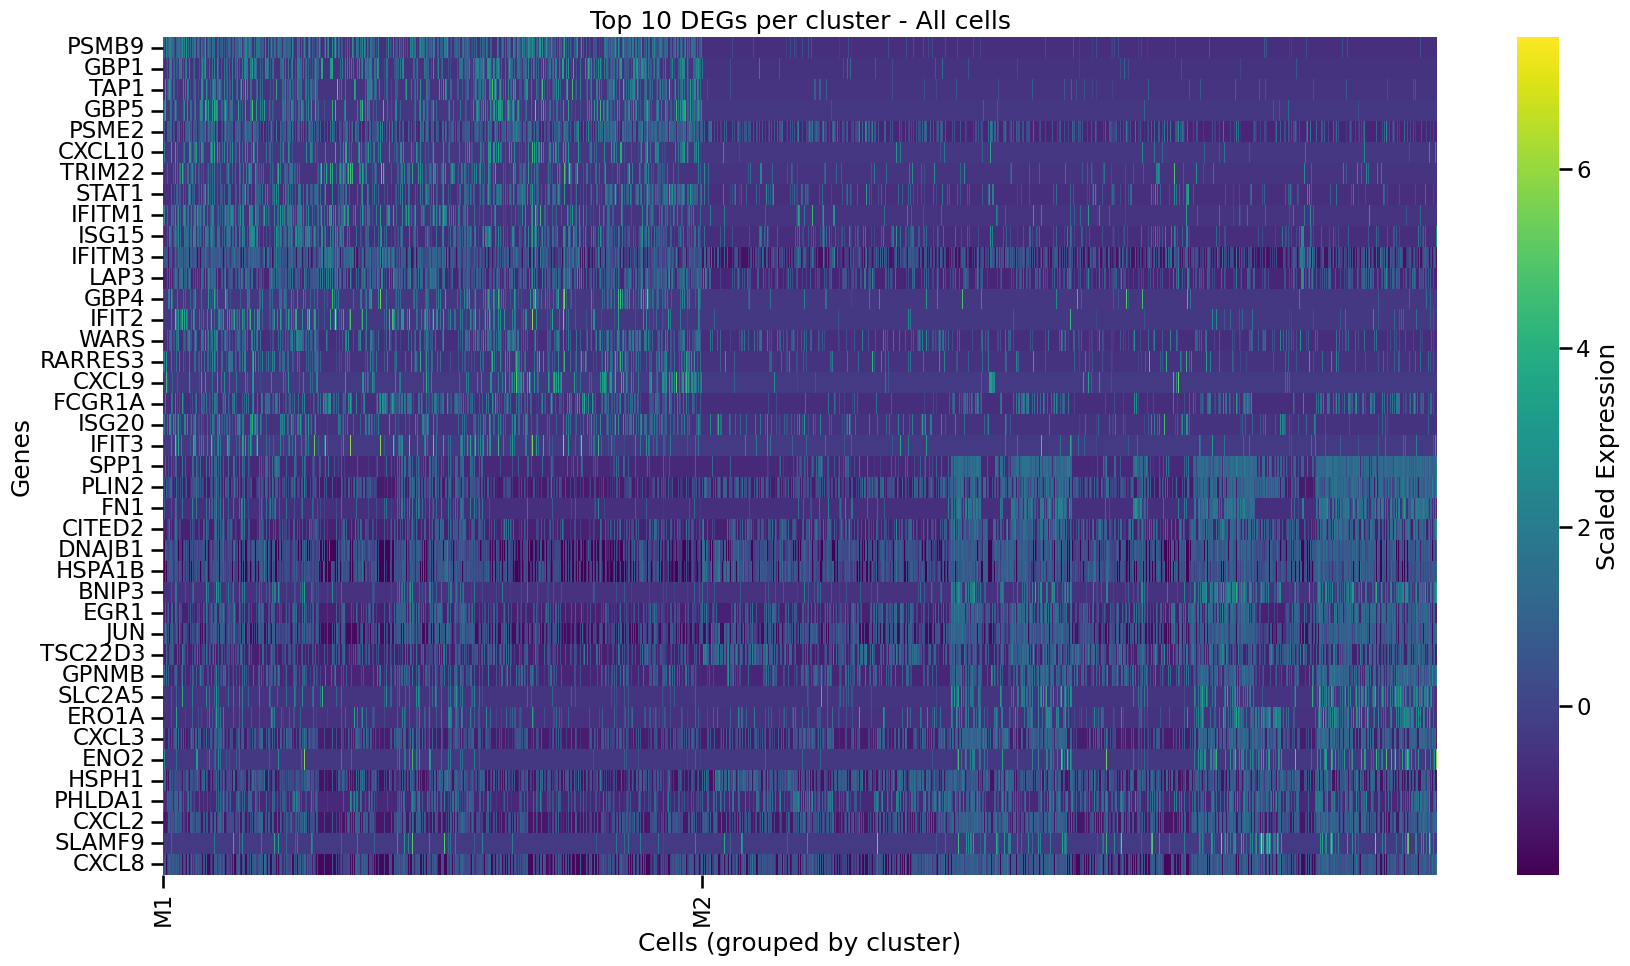

In [31]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# DEG 계산 (이미 수행했으면 생략 가능)
sc.tl.rank_genes_groups(predictadata, groupby='final_celltype', method='t-test')

# 클러스터별 top 10 gene 추출
top_genes_per_cluster = []
for cluster in predictadata.obs['final_celltype'].cat.categories:
    top_genes = predictadata.uns['rank_genes_groups']['names'][cluster][:20]
    top_genes_per_cluster.extend(top_genes)

# 중복 제거
top_genes_unique = list(pd.unique(top_genes_per_cluster))

# 데이터 스케일링
sc.pp.scale(predictadata, max_value=20)

# 유전자 발현 데이터 추출
data_matrix = predictadata[:, top_genes_unique].X
data_df = pd.DataFrame(data_matrix.toarray(), columns=top_genes_unique, index=predictadata.obs_names)

# 클러스터 정보 추가
data_df['cluster'] = predictadata.obs['final_celltype'].values

# 클러스터별로 정렬
data_df_sorted = data_df.sort_values('cluster')
cluster_labels = data_df_sorted['cluster']
data_df_sorted = data_df_sorted.drop(columns='cluster')

# 클러스터 위치 계산
cluster_positions = cluster_labels.reset_index(drop=True).groupby(cluster_labels.values).apply(lambda x: x.index[0])
cluster_names = cluster_positions.index.tolist()
cluster_ticks = cluster_positions.values

# 히트맵 그리기
plt.figure(figsize=(18, 10))
sns.heatmap(data_df_sorted.T, cmap='viridis', yticklabels=True, xticklabels=False,
            cbar_kws={'label': 'Scaled Expression'})

# 클러스터 라벨 추가
plt.xticks(cluster_ticks, cluster_names, rotation=90, ha='center')
plt.title('Top 10 DEGs per cluster - All cells')
plt.xlabel('Cells (grouped by cluster)')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()


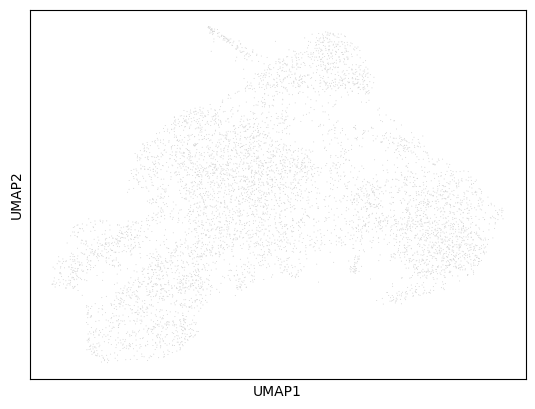

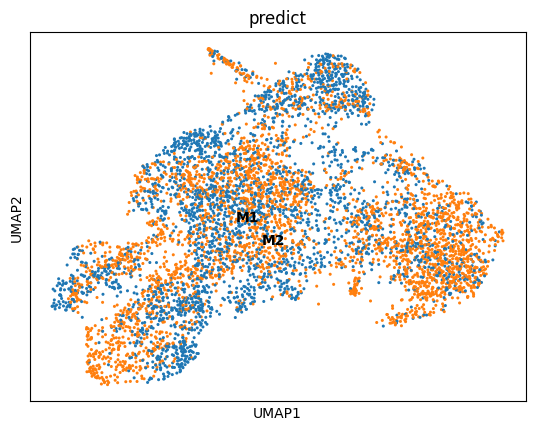

In [6]:
sc.pp.neighbors(predictadata)
sc.tl.leiden(predictadata, flavor="igraph", n_iterations=2)
sc.tl.umap(predictadata)
sc.pl.umap(
    predictadata,
    size=2,
)
sc.pl.umap(
    predictadata,
    color=['predict'],
    legend_loc="on data",
)